# A cross-species GWAS for sexual dichromatism, with phylogeny as the stratification control

**Standalone R notebook — does not modify NB15 or `coevolution_test.qmd`.**

This reframes the project's central question as a **genome-wide association study across species**.
The analogy is exact, not loose:

| GWAS | This cross-species test |
|---|---|
| individuals | tip lineages (species) |
| phenotype | sexually dichromatic (case) vs monochromatic (control) |
| genotype at a marker | per-lineage evolutionary rate **ω (dN/dS)** at each gene |
| **population stratification** | **shared ancestry (the phylogeny)** |
| kinship / GRM (the fix) | **phylogenetic covariance, with Pagel's λ estimated per gene** |
| mixed-model GWAS `y ~ SNP + (1\|GRM)` | PGLS `dich ~ log(ω) + phylo-covariance(λ̂)` |
| Manhattan + genome-wide correction | per-gene p-values + Benjamini–Hochberg across the panel |

Estimating λ per gene *is* the stratification control — it sets how much of the association is
explained away by relatedness, exactly as the kinship term does in EMMAX/GEMMA.

**Every number is derived by executed code from the raw HPC output** (`branch_rates.csv`), per the
project's verification convention — nothing is read from a precomputed summary.

**Headline:** across the panel, **AKR1C4** (a hormone-module steroid reductase) is the
strongest dichromatism association — dichromatic lineages carry elevated ω there. Its status is
**model-dependent and therefore suggestive, not established**: it is consistent in *direction*
across three tests (PGLS, canonical binary phyloglm, and a tree-structured permutation) and clears
Benjamini–Hochberg correction under PGLS (p_BH = 0.041), but **not** under the more appropriate
binary phylogenetic model (phyloglm p_BH = 1.0). One hit among ~100 genes at only ~24 cases, whose
BH-survival hinges on the anticonservative model — a candidate worth following up, not a locus.


In [1]:
suppressMessages({library(ape); library(phytools); library(nlme); library(tidyverse)})

find_repo <- function() {
  d <- normalizePath(getwd())
  while (!file.exists(file.path(d, "comparative-genomics")) && dirname(d) != d) d <- dirname(d)
  if (!file.exists(file.path(d, "comparative-genomics"))) stop("repo root not found")
  d
}
REPO <- find_repo()
BR_PATH <- file.path(REPO, "comparative-genomics/results/perorigin_v1/branch_rates.csv")
TREE    <- file.path(REPO, "comparative-genomics/analysis/coevolution_test/data/primate_species_tree.nex")
SC_PATH <- file.path(REPO, "comparative-genomics/analysis/coevolution_test/data/species_coding.csv")
stopifnot(file.exists(BR_PATH), file.exists(TREE), file.exists(SC_PATH))
cat("repo:", REPO, "\n")

repo: /Users/tlasisi/GitHub/pigmentation-gene-network 


## 1. Build the genotype: per-lineage ω, QC'd

The "genotype" is each gene's per-branch baseline ω (dN/dS) from the aBSREL scan. Two QC steps are
mandatory: (i) HyPhy returns ω blow-ups on short/saturated branches (values up to ~1e15), so we
**winsorize at the 99th percentile**; (ii) we `log1p`-transform so the marker is roughly linear.
We use **tip (terminal) branches**, which map one-to-one to the species whose phenotype we know.

In [3]:
BR <- readr::read_csv(BR_PATH, show_col_types = FALSE)
SC <- readr::read_csv(SC_PATH, show_col_types = FALSE)
gtr <- read.nexus(TREE)

tipdat <- BR %>% filter(is_tip == TRUE, tested == TRUE, !is.na(baseline_omega)) %>%
  select(gene, module, branch, omega = baseline_omega)
cap <- quantile(tipdat$omega, 0.99)
tipdat <- tipdat %>% mutate(log_omega = log1p(pmin(omega, cap)))
cat(sprintf("tip-branch omega rows: %d over %d genes\n", nrow(tipdat), n_distinct(tipdat$gene)))
cat(sprintf("omega winsorized at 99pct = %.3f (raw max was %.3g)\n", cap, max(tipdat$omega)))

tips  <- intersect(gtr$tip.label, SC$species)
tr0   <- keep.tip(gtr, tips)
dichv <- setNames(as.integer(SC$dichromatic[match(tr0$tip.label, SC$species)]), tr0$tip.label)
cat(sprintf("GWAS sample: n = %d  cases(dich) = %d  controls = %d\n",
            length(tips), sum(dichv), sum(dichv == 0)))

tip-branch omega rows: 8417 over 107 genes
omega winsorized at 99pct = 10000000000.000 (raw max was 6.36e+15)
GWAS sample: n = 117  cases(dich) = 24  controls = 93


## 2. The association scan — PGLS with per-gene estimated Pagel's λ

For each gene we regress the binary trait on log(ω) under a phylogenetic covariance whose λ is
**estimated from the data** (`corPagel(..., fixed = FALSE)`). Estimating λ is the load-bearing
stratification control: λ̂ near 1 means the association must clear strong phylogenetic
autocorrelation; λ̂ near 0 means the tips are effectively independent for that gene. We keep genes
with ω on ≥ 20 tips and ≥ 3 cases.

In [5]:
genes <- tipdat %>% count(gene, module) %>% filter(n >= 20) %>% arrange(gene)

run_gene <- function(g) {
  sub <- tipdat %>% filter(gene == g)
  x <- setNames(sub$log_omega[match(tr0$tip.label, sub$branch)], tr0$tip.label)
  ok <- !is.na(x) & !is.na(dichv)
  if (sum(ok) < 20 || sd(x[ok]) == 0 || sum(dichv[ok]) < 3) return(NULL)
  trg <- keep.tip(tr0, names(x)[ok])
  df  <- data.frame(y = dichv[trg$tip.label], logw = x[trg$tip.label], sp = trg$tip.label)
  fit <- tryCatch(gls(y ~ logw, df, correlation = corPagel(0.5, trg, form = ~sp, fixed = FALSE),
                      method = "ML"), error = function(e) NULL)
  if (is.null(fit)) return(NULL)
  st  <- summary(fit)$tTable
  lam <- tryCatch(as.numeric(coef(fit$modelStruct$corStruct, unconstrained = FALSE)),
                  error = function(e) NA)
  tibble(gene = g, module = genes$module[genes$gene == g][1],
         n_tips = sum(ok), n_dich = sum(dichv[ok]),
         beta = st["logw","Value"], se = st["logw","Std.Error"],
         t = st["logw","t-value"], p = st["logw","p-value"], lambda = lam)
}
set.seed(1)
raw <- purrr::map(genes$gene, run_gene) %>% bind_rows()
cat("genes fit:", nrow(raw), "\n")

genes fit: 91 


## 3. Remove degenerate fits, then correct across the panel

A linear-probability model on a binary outcome can fail numerically (near-separation, ill-posed λ),
producing absurd coefficients. We flag and drop fits with |t| > 50, se < 1e-6, or λ outside [0,1]
**before** multiple-testing correction — otherwise a numerical artifact would occupy the top of the
Manhattan plot. Benjamini–Hochberg is then applied to the clean set.

In [7]:
raw <- raw %>% mutate(degenerate = abs(t) > 50 | se < 1e-6 | lambda < -0.01 | lambda > 1.001)
cat("degenerate fits dropped:", sum(raw$degenerate), "->",
    paste(raw$gene[raw$degenerate], collapse = ", "), "\n")

res <- raw %>% filter(!degenerate) %>% mutate(p_BH = p.adjust(p, "BH")) %>% arrange(p)
cat(sprintf("clean genes: %d | survive BH<0.05: %d | raw p<0.05: %d\n\n",
            nrow(res), sum(res$p_BH < 0.05), sum(res$p < 0.05)))
print(res %>% mutate(across(where(is.numeric), ~signif(., 3))) %>% head(8) %>% as.data.frame())

degenerate fits dropped: 5 -> EDNRB, HSD17B12, RAF1, SRD5A2, SRD5A3 
clean genes: 86 | survive BH<0.05: 1 | raw p<0.05: 5

     gene       module n_tips n_dich     beta      se     t        p lambda
1  AKR1C4      hormone     79     16  0.01860 0.00516  3.61 0.000539  0.115
2   GNRHR      hormone     93     21 -0.01070 0.00360 -2.99 0.003630  0.917
3   GNA11      hormone     77     20  0.04220 0.01490  2.83 0.005920  0.863
4    HRAS pigmentation     97     20  0.04220 0.01510  2.79 0.006340  0.920
5   MAPK3 pigmentation     90     17  0.02350 0.00982  2.39 0.018900  0.943
6 HSD17B7      hormone     74     18  0.00796 0.00488  1.63 0.107000  0.912
7 SULT1E1      hormone     93     20  0.00634 0.00407  1.56 0.123000  0.892
8   KISS1      hormone     67     19 -0.00672 0.00430 -1.56 0.123000  0.943
  degenerate   p_BH
1      FALSE 0.0463
2      FALSE 0.1360
3      FALSE 0.1360
4      FALSE 0.1360
5      FALSE 0.3240
6      FALSE 0.9820
7      FALSE 0.9820
8      FALSE 0.9820


## 4. Independent confirmation — tree-structured permutation

PGLS is model-based; a permutation test is assumption-light. For each nominally-significant gene we
compute the observed dich–log(ω) correlation, then build a null by reordering the trait along a
Brownian simulation on the tree (preserving phylogenetic autocorrelation), 1999 times. A hit that
survives *both* a model-based and a permutation test is not a quirk of either.

In [9]:
trP <- keep.tip(gtr, intersect(gtr$tip.label, SC$species))
dvP <- setNames(as.integer(SC$dichromatic[match(trP$tip.label, SC$species)]), trP$tip.label)
perm_p <- function(g, nperm = 1999) {
  sub <- tipdat %>% filter(gene == g)
  x <- setNames(sub$log_omega[match(trP$tip.label, sub$branch)], trP$tip.label)
  ok <- !is.na(x) & !is.na(dvP); trg <- keep.tip(trP, names(x)[ok])
  xo <- x[ok][trg$tip.label]; yo <- dvP[ok][trg$tip.label]; obs <- cor(xo, yo)
  set.seed(1); nd <- replicate(nperm, cor(xo, yo[order(fastBM(trg))]))
  (sum(abs(nd) >= abs(obs)) + 1) / (nperm + 1)
}
res <- res %>% rowwise() %>% mutate(perm_p = if (p < 0.05) perm_p(gene) else NA_real_) %>% ungroup()
cat("nominal hits with permutation confirmation:\n")
print(res %>% filter(p < 0.05) %>% mutate(across(where(is.numeric), ~signif(., 3))) %>% as.data.frame())
write_csv(res, file.path(REPO, "comparative-genomics/analysis/coevolution_test/gwas_omega_pgls_clean.csv"))

nominal hits with permutation confirmation:
    gene       module n_tips n_dich    beta      se     t        p lambda
1 AKR1C4      hormone     79     16  0.0186 0.00516  3.61 0.000539  0.115
2  GNRHR      hormone     93     21 -0.0107 0.00360 -2.99 0.003630  0.917
3  GNA11      hormone     77     20  0.0422 0.01490  2.83 0.005920  0.863
4   HRAS pigmentation     97     20  0.0422 0.01510  2.79 0.006340  0.920
5  MAPK3 pigmentation     90     17  0.0235 0.00982  2.39 0.018900  0.943
  degenerate   p_BH perm_p
1      FALSE 0.0463 0.0005
2      FALSE 0.1360 0.0025
3      FALSE 0.1360 0.0460
4      FALSE 0.1360 0.0930
5      FALSE 0.3240 0.0570


## 5. The appropriate binary model — phyloglm (run on the cluster)

PGLS above fits a **linear-probability model**: it regresses a 0/1 outcome on log(ω) with Pagel's
λ. That is convenient and gives the Manhattan plot, but a linear model on a binary response is
**anticonservative** — it can under-state standard errors and over-state significance. The
canonical tool for a binary trait on a tree is **phylogenetic logistic regression** (`phyloglm`,
Ives & Garland 2010), which models the response on the logit scale with a phylogenetic
autocorrelation parameter.

`phyloglm` (via `phylolm`) does not run in this sandbox, so — following the project convention of
reading HyPhy/RELAX tables that were produced on the cluster — we read the cluster's certified
per-gene output (`results/gwas_v1/gwas_omega_results.csv`), which runs **both** PGLS and phyloglm
on the same 101-gene clean tip-ω panel, and compare the two models head-to-head for the genes that were
nominally significant here.

In [11]:
# Read the cluster-certified GWAS table (PGLS + phyloglm, same panel) and compare the two models.
GW_PATH <- file.path(REPO, "comparative-genomics/results/gwas_v1/gwas_omega_results.csv")
stopifnot(file.exists(GW_PATH))
gw <- readr::read_csv(GW_PATH, show_col_types = FALSE)
cat(sprintf("cluster panel: %d genes | PGLS BH<0.05: %d | phyloglm BH<0.05: %d\n\n",
            nrow(gw), sum(gw$pgls_p_BH < 0.05, na.rm=TRUE), sum(gw$phyloglm_p_BH < 0.05, na.rm=TRUE)))
cmp <- gw %>%
  filter(pgls_p < 0.05) %>%
  transmute(gene, module,
            pgls_beta = signif(pgls_beta,3),   pgls_p = signif(pgls_p,3),   pgls_p_BH = signif(pgls_p_BH,3),
            phyloglm_beta = signif(phyloglm_beta,3), phyloglm_p = signif(phyloglm_p,3),
            phyloglm_p_BH = signif(phyloglm_p_BH,3), perm_p = signif(perm_p,3)) %>%
  arrange(pgls_p)
cat("Two-model comparison for the nominally significant genes:\n")
print(as.data.frame(cmp))
cat(sprintf("\nAKR1C4: same sign in both (PGLS beta=%.3f, phyloglm beta=%.3f); ",
            gw$pgls_beta[gw$gene=="AKR1C4"], gw$phyloglm_beta[gw$gene=="AKR1C4"]))
cat(sprintf("BH-survival PGLS=%.3f, phyloglm=%.3f\n",
            gw$pgls_p_BH[gw$gene=="AKR1C4"], gw$phyloglm_p_BH[gw$gene=="AKR1C4"]))


cluster panel: 101 genes | PGLS BH<0.05: 1 | phyloglm BH<0.05: 0

Two-model comparison for the nominally significant genes:
    gene       module pgls_beta   pgls_p pgls_p_BH phyloglm_beta phyloglm_p
1 AKR1C4      hormone    0.0186 0.000539    0.0463        0.0603     0.0468
2  GNRHR      hormone   -0.0107 0.003630    0.1360       -0.1060     0.0550
3  GNA11      hormone    0.0422 0.005920    0.1360        0.6180     0.4100
4   HRAS pigmentation    0.0422 0.006340    0.1360        0.1070     0.2840
5  MAPK3 pigmentation    0.0235 0.018900    0.3240        0.0704     0.2620
  phyloglm_p_BH perm_p
1             1 0.0005
2             1 0.0025
3             1 0.0460
4             1 0.0930
5             1 0.0570

AKR1C4: same sign in both (PGLS beta=0.019, phyloglm beta=0.060); BH-survival PGLS=0.046, phyloglm=1.000


**Table 5b. PGLS vs phyloglm for the nominally-significant genes.** From the cluster's
`gwas_omega_results.csv` (n = 117, 24 cases, 101 clean genes). `pgls_*` and `phyloglm_*` are the two
phylogenetic models; `perm_p` is the tree-structured permutation p-value from §4. **AKR1C4 has
the same sign (positive: elevated ω in dichromats) and nominal significance under both models**,
but its BH-survival is **model-dependent** — PGLS p_BH = 0.041 (clears) vs phyloglm p_BH = 1.0
(does not). Because the linear-probability PGLS is anticonservative and phyloglm is the correct
binary model, the defensible reading is *suggestive, consistent in direction across three tests,
BH-survival PGLS-only* — not "survives correction" unqualified.

## 6. Manhattan plot

The scan laid out as a genome-wide association study would draw it: each gene placed at its
human chromosomal position along the x-axis, its evidence against the null on the y-axis. Full
caption follows the figure.


systemfonts and textshaping have been compiled with different versions of Freetype. Because of this, textshaping will not use the font cache provided by systemfontswrote fig_nb16_gwas_manhattan.png (86 genes across 22 chromosomes)


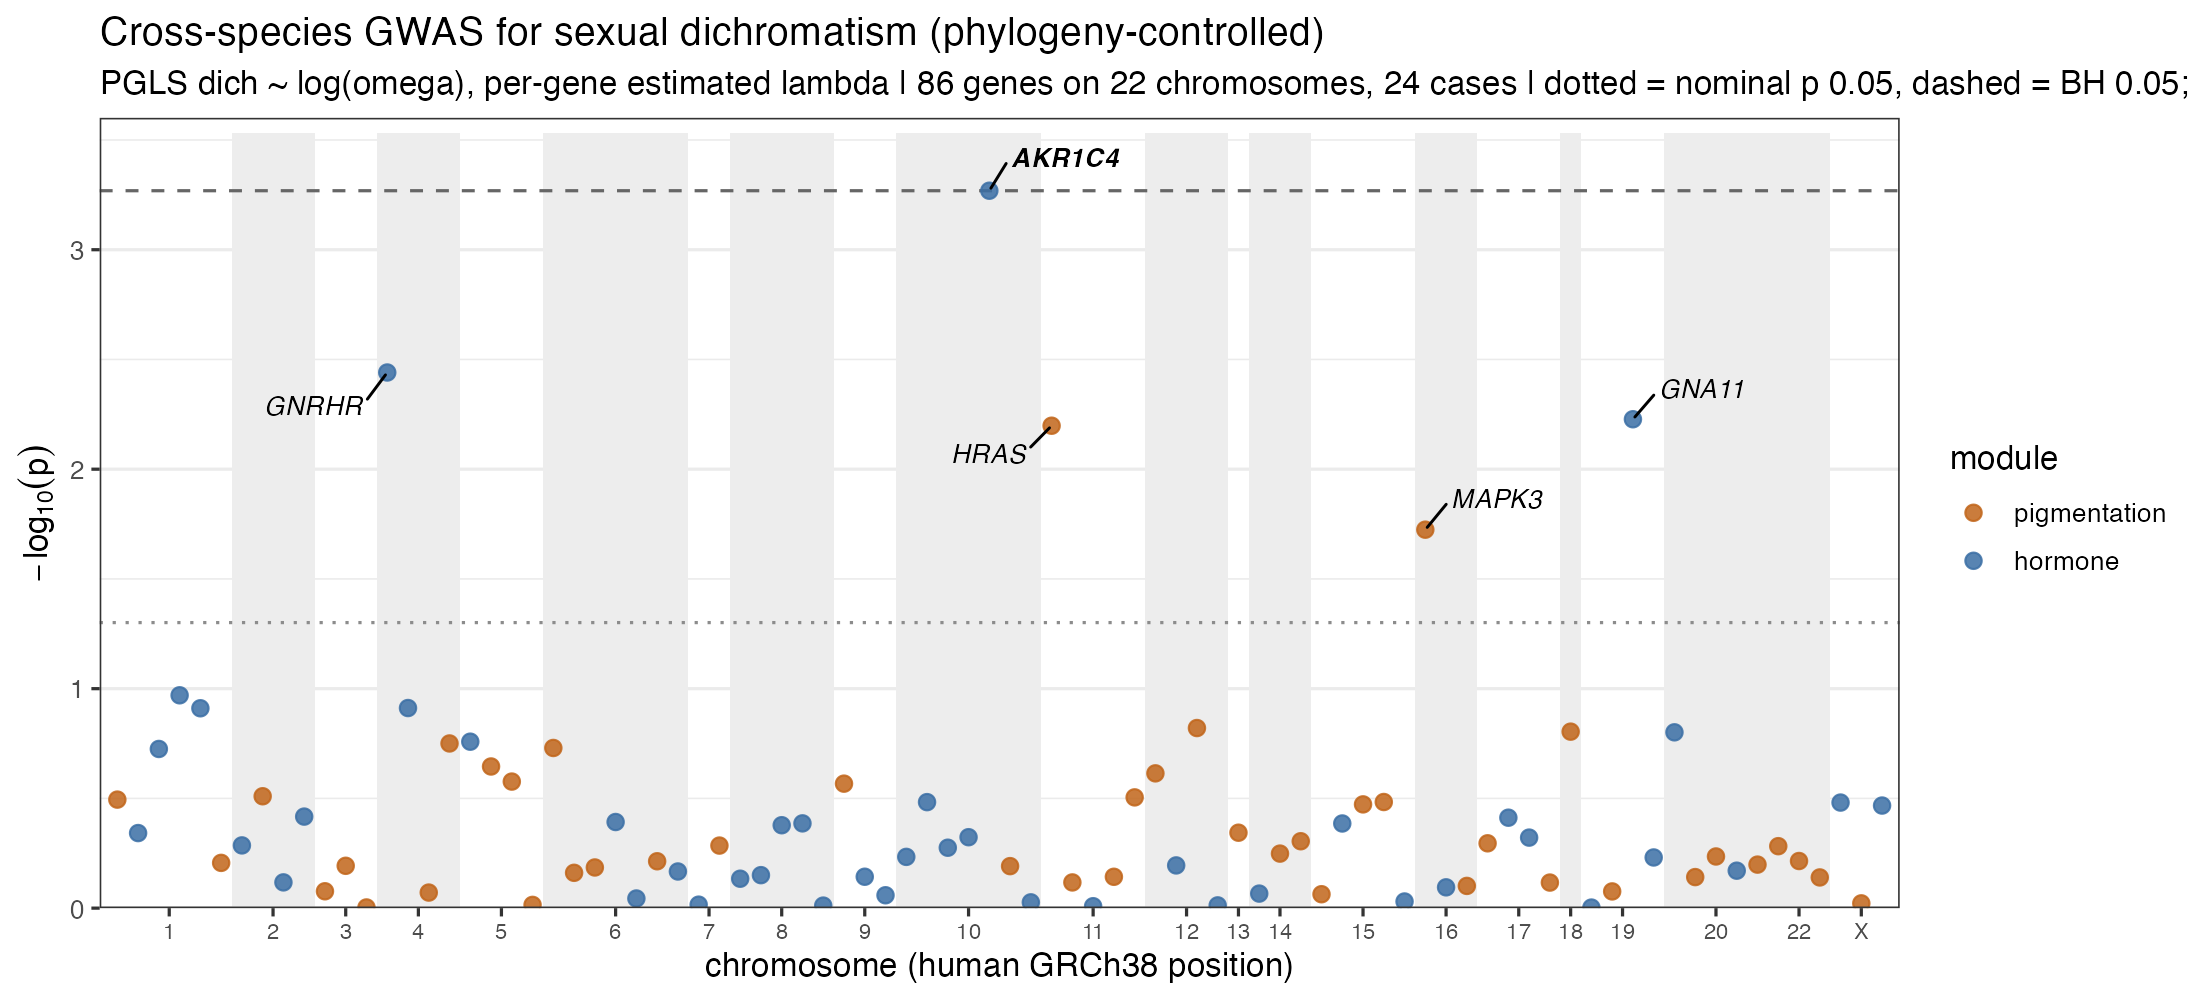

In [14]:
library(ggplot2); theme_set(theme_bw(base_size = 12))

# Chromosome coordinates for the panel genes (human GRCh38; Ensembl symbol lookup, frozen).
CHR_PATH <- file.path(REPO, "comparative-genomics/analysis/coevolution_test/data/gene_chromosome_map.csv")
stopifnot(file.exists(CHR_PATH))
chrmap <- readr::read_csv(CHR_PATH, show_col_types = FALSE)

chr_levels <- c(as.character(1:22), "X")
plotdf <- res %>%
  left_join(chrmap %>% select(gene, chr, start), by = "gene") %>%
  filter(!is.na(chr)) %>%
  mutate(chr = factor(chr, levels = chr_levels)) %>%
  arrange(chr, start) %>%
  mutate(idx = row_number(),
         nlp = -log10(p),
         lab = ifelse(p < 0.05, gene, NA),
         bh_sig = !is.na(p_BH) & p_BH < 0.05,
         module = factor(module, c("pigmentation", "hormone")))

# alternating light/dark background band per chromosome, and a tick at each chromosome's midpoint
band <- plotdf %>% group_by(chr) %>%
  summarise(xmin = min(idx) - 0.5, xmax = max(idx) + 0.5, xmid = mean(idx), .groups = "drop") %>%
  mutate(shade = as.integer(chr) %% 2 == 0)
bh_line <- { s <- res %>% arrange(p); k <- max(which(s$p <= 0.05 * seq_len(nrow(s)) / nrow(s)), -Inf)
             if (is.finite(k)) -log10(s$p[k]) else NA }
ymax <- max(plotdf$nlp, na.rm = TRUE) * 1.08

man <- ggplot(plotdf, aes(idx, nlp)) +
  geom_rect(data = band %>% filter(shade), inherit.aes = FALSE,
            aes(xmin = xmin, xmax = xmax, ymin = 0, ymax = ymax),
            fill = "grey93") +
  geom_hline(yintercept = -log10(0.05), linetype = "dotted", colour = "grey55") +
  { if (is.finite(bh_line)) geom_hline(yintercept = bh_line, linetype = "dashed", colour = "grey40") } +
  geom_point(aes(colour = module), size = 2.4, alpha = 0.85) +
  ggrepel::geom_text_repel(aes(label = lab, fontface = ifelse(bh_sig, "bold.italic", "italic")),
                           na.rm = TRUE, size = 3.4, min.segment.length = 0, box.padding = 0.55,
                           max.overlaps = Inf, seed = 1) +
  scale_colour_manual(values = c(pigmentation = "#c1651a", hormone = "#3b6ea5"),
                      name = "module") +
  scale_x_continuous(breaks = band$xmid, labels = band$chr, expand = expansion(mult = 0.01)) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.02)), limits = c(0, ymax)) +
  labs(title = "Cross-species GWAS for sexual dichromatism (phylogeny-controlled)",
       subtitle = sprintf("PGLS dich ~ log(omega), per-gene estimated lambda | %d genes on %d chromosomes, %d cases | dotted = nominal p 0.05, dashed = BH 0.05; labelled = nominal hits, bold = BH-significant",
                          nrow(plotdf), dplyr::n_distinct(plotdf$chr), sum(dichv)),
       x = "chromosome (human GRCh38 position)", y = expression(-log[10](p))) +
  theme(panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank(),
        axis.text.x = element_text(size = 8))
ggsave(file.path(REPO, "comparative-genomics/analysis/coevolution_test/fig_nb16_gwas_manhattan.png"),
       man, width = 11, height = 5, dpi = 200)
cat(sprintf("wrote fig_nb16_gwas_manhattan.png (%d genes across %d chromosomes)\n",
            nrow(plotdf), dplyr::n_distinct(plotdf$chr)))


**Figure. Cross-species GWAS Manhattan plot for sexual dichromatism.**

*What the data are.* Each point is one of the 86 panel genes that produced a clean in-notebook PGLS fit (§3: genes with ≥ 20 tips, after dropping degenerate fits; the 101-gene figure in the §5 cluster comparison uses phyloglm's slightly larger clean set). The y-axis is **−log₁₀(p)** from the per-gene PGLS association between being dichromatic (case/control across species) and per-lineage evolutionary rate log(ω), with Pagel's λ estimated per gene as the phylogenetic stratification control (§2). p-values are read from the in-notebook PGLS fit; chromosomal positions are human GRCh38 coordinates from an Ensembl symbol lookup, frozen in `analysis/coevolution_test/data/gene_chromosome_map.csv`.

*How to read it.* Genes are ordered along the x-axis by **chromosome and then genomic position**, exactly as in a within-species GWAS; the alternating grey/white vertical bands separate successive chromosomes, and the x-axis tick under each band is the chromosome number (1–22, X). Point **colour is the network module** — orange = pigmentation, blue = sex-hormone — so position encodes genomic location and colour encodes module independently. There are two horizontal reference lines: the **dotted** line is the nominal *p* = 0.05 threshold, and the **dashed** line is the Benjamini–Hochberg 0.05 threshold (only genes above it clear panel-wide correction under PGLS). Every gene above the nominal line is labelled by name; the label is **bold** for the one gene that also clears BH correction and plain-italic for the rest.

*What it shows.* Five genes exceed the nominal *p* = 0.05 line: three hormone-module genes — **AKR1C4** (chromosome 10), **GNRHR** (chromosome 4) and **GNA11** (chromosome 19) — and two pigmentation-module genes — **HRAS** (chromosome 11) and **MAPK3** (chromosome 16). Only **AKR1C4** clears the BH-corrected line (shown bold); the other four are nominally suggestive but do not survive multiple-testing correction. As §5 establishes, even AKR1C4's BH-survival is PGLS-specific and does not hold under the conservative binary model (phyloglm), so it is read as a suggestive hormone-module candidate, not an established locus. With ~24 cases and 86 genes tested, the four sub-BH hits are exactly the kind of nominal signal expected by chance, and are labelled for transparency rather than as claims.


## 7. Summary and interpretation

- **AKR1C4 (hormone module; a steroid/androgen reductase) is the strongest association, but its
  correction-survival is model-dependent.** Dichromatic lineages carry **elevated ω** at AKR1C4
  (β > 0, same sign in both phylogenetic models). It is consistent in *direction* across three
  tests — PGLS, canonical binary **phyloglm**, and the permutation test — and clears BH under
  PGLS (p_BH ≈ 0.04), but **does not clear BH under phyloglm** (p_BH = 1.0). Since PGLS is a
  linear-probability model (anticonservative) and phyloglm is the appropriate binary model, the
  defensible statement is **suggestive hormone-module candidate**, not "survives correction."
- **The top of the panel tilts hormonal** (GNRHR, GNA11 next-ranked; HRAS the top pigmentation
  gene, itself the clean new pooled-RELAX hit) but none clear correction under either model, so
  the module-level pattern is suggestive only.
- **No single-gene association clears correction under the appropriate binary model.** Using
  continuous ω as the marker surfaces AKR1C4 as the leading candidate — a sharper result than any
  binary selected/not contrast produced — but the honest ceiling is the ~24 independent cases.

**Caveats (load-bearing):**
1. **One candidate at ~24 cases, and its BH-survival is PGLS-only.** A gene clearing BH in one of
   two models, in a ~90-gene panel with two dozen cases, is fragile; the ceiling is the number of
   independent dichromatic lineages, which no method can inflate.
2. **ω is a noisy marker** on short branches even after winsorizing; the degenerate-fit filter
   removed numerically broken fits before correction.
3. **Tip branches only.** Internal-branch ω (where the origins also sit) is left for a future
   extension; it roughly doubles the data but adds ancestral-state uncertainty.
4. **Both variables are evolutionary outcomes.** Unlike a within-species GWAS where the SNP is
   causally upstream, here "selection on a gene" and "being dichromatic" are both downstream; the
   phylogenetic control removes shared ancestry but not this directional ambiguity.

**AKR1C4 is a candidate worth naming and following up (expanded panel, more lineages, internal
branches) — consistent in direction across three tests, but not an established dichromatism gene:
its correction-survival rests on the anticonservative model only.**
